In [1]:
# import necessary libraies
import pandas as pd # data manipulation
import numpy as np # vectorized math
import matplotlib.pyplot as plt # visulization tool 
import seaborn as sns

# import pre-created dataset
from sklearn.datasets import load_breast_cancer

In [5]:
 # store dataset inside of object
cancer = load_breast_cancer()

In [6]:
# view keys 
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [10]:
# create dataframe 
df = pd.DataFrame(cancer['data'], columns = cancer['feature_names'])

# view resuly
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
# view predictions
cancer['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [12]:
# target values
cancer['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [13]:
# scale data (PCA requires standardization to avoid large values dominating the model)
from sklearn.preprocessing import StandardScaler

# instantiation processs
scaler = StandardScaler()

# scale data 
scaled_data = scaler.fit_transform(df)




In [15]:
# PCA Phase 
from sklearn.decomposition import  PCA 

# begin instantation process and choose number of new features created 
pca = PCA(n_components= 2)

# transform scaled_data into PCA (This process should only include 2 new feature curated from the orginal )
X_pca = pca.fit_transform(scaled_data)

# print shape to view if process went well
print(scaled_data.shape)
print(X_pca.shape)



(569, 30)
(569, 2)


Text(0, 0.5, 'Cumalative Variance')

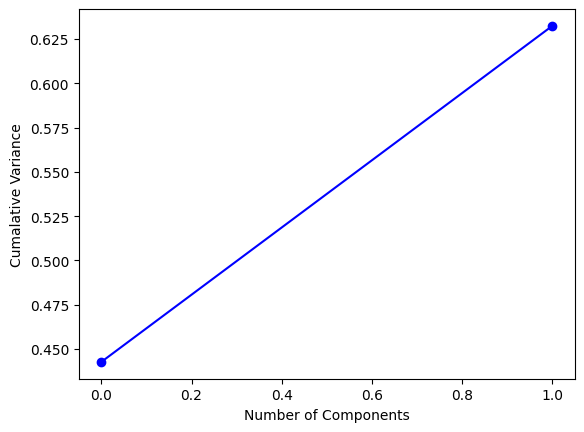

In [21]:
# elbow plot (if you want to find the optimal amout of component, use a elbow plot. This shpws you how much informayion (variance) each component adds to the model) 

plt.plot(np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumalative Variance')

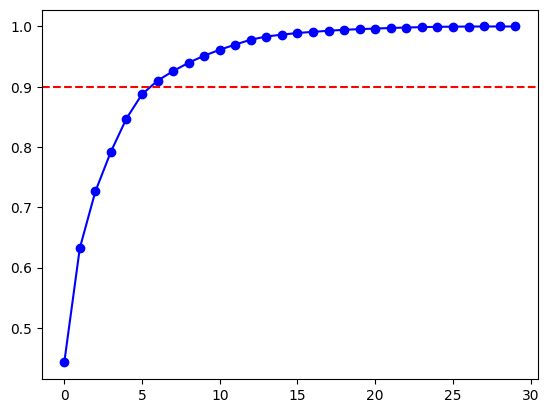

In [27]:
# The PCA is only capturing 63% of the information in the dataset using only two components. The goal is to aim for an 90% - 95%, to ensure the model doesn't miss key patterns. 
# The fix? Create a new PCA instantiation and give it the ability to choose the right amount of components needs to ensure an 95% explained variance 

# Let PCA Calculate all possible points
pca_full = PCA().fit(scaled_data)

# re-plot 
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), 'bo-')
plt.axhline(y=0.90, color = 'r', linestyle = '--') # add's 90% goal line
plt.show()

In [33]:
# Based on the visualiztion the required number of components to reach 90% of explained variance is in betweem 7-10.
# Now that we understand this from a interval perspective, let's allow Scikit-learn to do the hardwork for us and cross-referenece the output with the visualization 

# automatically picks the number of components in the instantiation phase 
pca_auto = PCA(n_components= 0.95)
X_pca = pca_auto.fit_transform(scaled_data)

print(f'Number of Components {pca_auto.n_components_}')

Number of Components 10


In [34]:
# A number of 10 component is the confirmed value for the PCA model. 
# Note: You can not say "X is associated with Y". The correct framing would be 'Component 1 caused Y" 

In [ ]:
# store component values into dataframe 
df_comp = pd.DataFrame(pca_.components_, columns = cancer['feature_names'])

# view result 
df_comp.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
1,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339
2,-0.008531,0.064550,-0.009314,0.028700,-0.104292,-0.074092,0.002734,-0.025564,-0.040240,-0.022574,...,-0.047507,-0.042298,-0.048547,-0.011902,-0.259798,-0.236076,-0.173057,-0.170344,-0.271313,-0.232791
3,-0.041409,0.603050,-0.041983,-0.053434,-0.159383,-0.031795,-0.019123,-0.065336,-0.067125,-0.048587,...,-0.015417,0.632808,-0.013803,-0.025895,-0.017652,0.091328,0.073951,-0.006007,0.036251,0.077053
4,-0.037786,0.049469,-0.037375,-0.010331,0.365089,-0.011704,-0.086375,0.043861,0.305941,0.044424,...,0.004407,0.092883,-0.007454,0.027391,0.324435,-0.121804,-0.188519,-0.043332,0.244559,-0.094423


<Axes: >

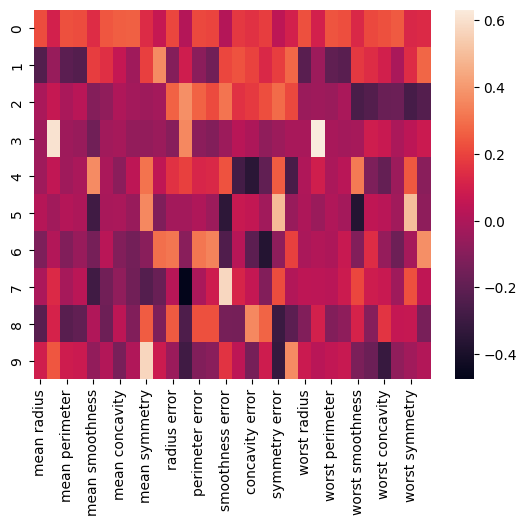

In [39]:
# create heatmap
sns.heatmap(data = df_comp)

In [45]:
# show top 5 feature for first component
print(f'---- PC1 Top Features ----')
print(df_comp.iloc[0].sort_values(ascending = False).head(5))

# show top 5 for the second component 
print(f'---- PC2 Top Features ----')
print(df_comp.iloc[1].sort_values(ascending = False).head(5))

# show top 5 for the third component
print(f'---- PC3 Top Features ----- ')
print(df_comp.iloc[2].sort_values(ascending = False).head(5))

---- PC1 Top Features ----
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: 0, dtype: float64
---- PC2 Top Features ----
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
compactness error          0.232716
smoothness error           0.204430
Name: 1, dtype: float64
---- PC3 Top Features ----- 
texture error       0.374634
smoothness error    0.308839
symmetry error      0.288584
radius error        0.268481
perimeter error     0.266645
Name: 2, dtype: float64
